# Phase 1 Naive_Bayes

## Objective
Compare Flatten, PCA, and HOG feature representations for binary MNIST classification with Naive Bayes.

## What This Notebook Shows
1. Load the MNIST dataset and filter it into two target classes  
2. Inspect class distribution and visualize sample images  
3. Apply preprocessing and prepare train/test splits  
4. Compare Flatten, PCA, and HOG feature extraction methods  
5. Train Naive Bayes
6. Evaluate results using accuracy, confusion matrix, and error analysis  
7. Identify and present the best-performing configuration

## 1) Environment Setup and Imports

In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, repo_root)

from src.utils.mnist_features import load_mnist, select_binary_classes, split_data, balance_binary_classes, normalize_data, build_features, class_distribution
from src.utils.evaluation import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, per_class_accuracy
from src.models.Naive_Bayes import NaiveBayes

In [3]:
# Explicit experiment config
RANDOM_STATE = 42
DATA_PATH = "../../data/mnist.npz"

CLASS_A = 8
CLASS_B = 9
TEST_SIZE = 0.2
VAL_SIZE = 0.2

# Optional class-imbalance handling (applied on train split only).
APPLY_CLASS_BALANCING = True
BALANCE_METHOD = "undersample"

FEATURES = ["flatten", "pca", "hog"]

print("RANDOM_STATE:", RANDOM_STATE)
print("CLASSES:", (CLASS_A, CLASS_B))
print("FEATURES:", FEATURES)
print("DATA_PATH:", DATA_PATH)
print("APPLY_CLASS_BALANCING:", APPLY_CLASS_BALANCING)
print("BALANCE_METHOD:", BALANCE_METHOD)

RANDOM_STATE: 42
CLASSES: (8, 9)
FEATURES: ['flatten', 'pca', 'hog']
DATA_PATH: ../../data/mnist.npz
APPLY_CLASS_BALANCING: True
BALANCE_METHOD: undersample


## 2) Load and Inspect MNIST Dataset

Full dataset shape: (70000, 28, 28), Labels shape: (70000,)
Binary subset (classes 8 & 9): 13783 samples
Class distribution: {8: 6825, 9: 6958}


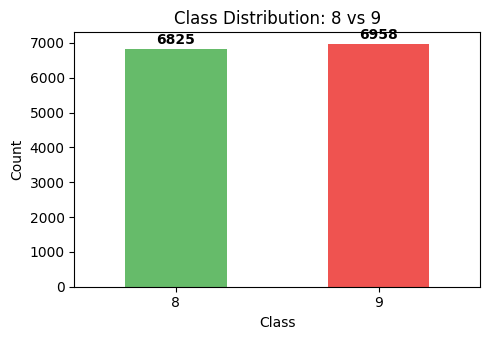

In [4]:
# Load the full MNIST dataset
x_all, y_all = load_mnist('../../data/mnist.npz')
print(f'Full dataset shape: {x_all.shape}, Labels shape: {y_all.shape}')

x_binary, y_binary = select_binary_classes(x_all, y_all, CLASS_A, CLASS_B)
print(f'Binary subset (classes {CLASS_A} & {CLASS_B}): {x_binary.shape[0]} samples')
print('Class distribution:', class_distribution(y_binary))

label_counts = pd.Series(y_binary).value_counts().reindex([CLASS_A, CLASS_B], fill_value=0)

plt.figure(figsize=(5, 3.5))
ax = label_counts.plot(kind='bar', color=['#66bb6a', '#ef5350'], rot=0)
for bar in ax.patches:
    height = bar.get_height()
    ax.text( bar.get_x() + bar.get_width() / 2, height + max(label_counts) * 0.01, f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold' )
plt.title(f'Class Distribution: {CLASS_A} vs {CLASS_B}')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

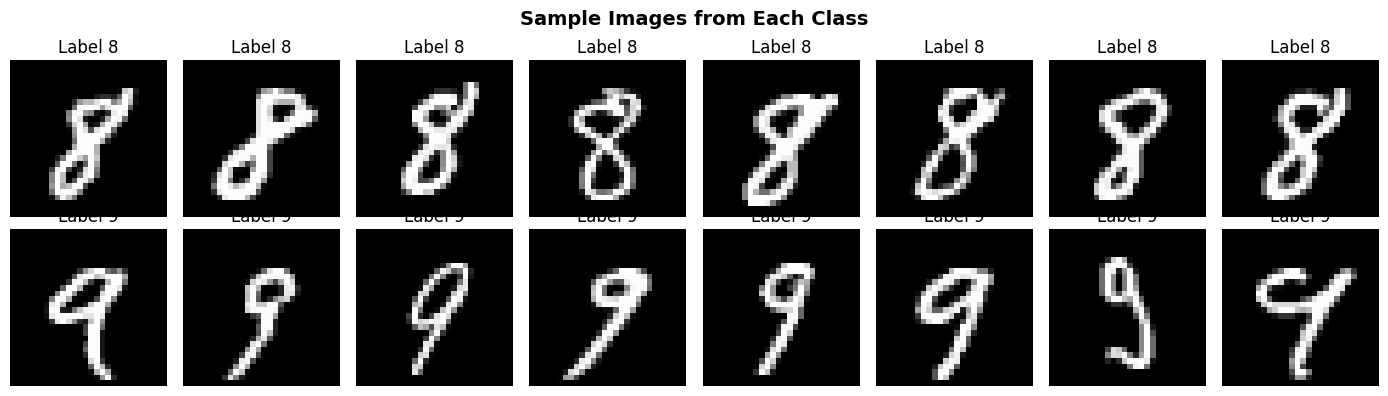

In [5]:
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for row, label in enumerate([CLASS_A, CLASS_B]):
    idxs = np.where(y_binary == label)[0][:8]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(x_binary[idx], cmap='gray')
        axes[row, col].set_title(f'Label {label}')
        axes[row, col].axis('off')
fig.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Train: 8271,  Val: 2756,  Test: 2756
Train distribution: {8: 4115, 9: 4156}
Val distribution: {8: 1382, 9: 1374}
Test distribution: {8: 1328, 9: 1428}


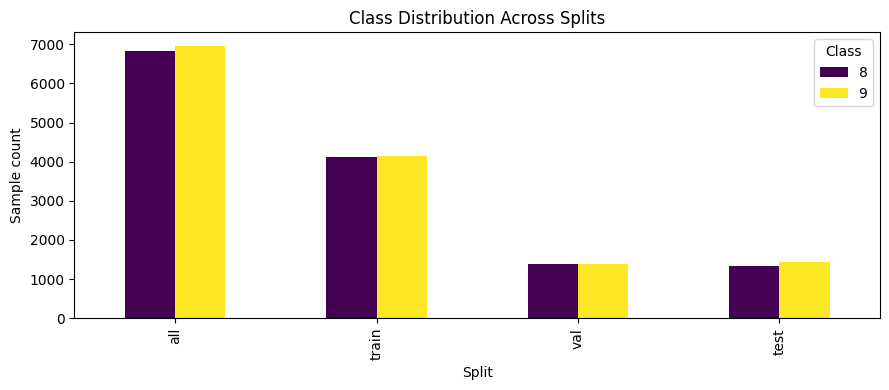

In [6]:
x_train, y_train, x_val, y_val, x_test, y_test = split_data(
    x_binary, y_binary, TEST_SIZE, VAL_SIZE, RANDOM_STATE
)

print(f'Train: {len(y_train)},  Val: {len(y_val)},  Test: {len(y_test)}')
print('Train distribution:', class_distribution(y_train))
print('Val distribution:', class_distribution(y_val))
print('Test distribution:', class_distribution(y_test))

# Visualization 
counts_all = class_distribution(y_binary)
counts_train = class_distribution(y_train)
counts_val = class_distribution(y_val)
counts_test = class_distribution(y_test)

split_df = pd.DataFrame(
    {
        'all': [counts_all.get(CLASS_A, 0), counts_all.get(CLASS_B, 0)],
        'train': [counts_train.get(CLASS_A, 0), counts_train.get(CLASS_B, 0)],
        'val': [counts_val.get(CLASS_A, 0), counts_val.get(CLASS_B, 0)],
        'test': [counts_test.get(CLASS_A, 0), counts_test.get(CLASS_B, 0)],
    },
    index=[CLASS_A, CLASS_B],
)

ax = split_df.T.plot(kind='bar', figsize=(9, 4), colormap='viridis')
ax.set_title('Class Distribution Across Splits')
ax.set_xlabel('Split')
ax.set_ylabel('Sample count')
ax.legend(title='Class')
plt.tight_layout()
plt.show()

## 3) Preprocessing 
1. Balance Training Set
2. Normalize Pixel Values

In [7]:
# Balance Training Set
x_train, y_train = balance_binary_classes(x_train, y_train,'undersample', RANDOM_STATE)
print(f'Balanced train size: {len(y_train)}')
print('Balanced distribution:', class_distribution(y_train))

Balanced train size: 8230
Balanced distribution: {8: 4115, 9: 4115}


In [8]:
# Normalize Pixel Values
x_train = normalize_data(x_train)
x_val   = normalize_data(x_val)
x_test  = normalize_data(x_test)
print(f'Pixel range after normalization: [{x_train.min():.1f}, {x_train.max():.1f}]')

Pixel range after normalization: [0.0, 1.0]


## 4) Feature Extraction
We compare three feature extraction methods:
- **Flatten**: Reshape each 28×28 image into a 784-dimensional vector
- **HOG**: Histogram of Oriented Gradients – captures edge/shape information
- **PCA**: Principal Component Analysis – reduces dimensionality while preserving 95% variance

In [9]:

feature_methods = ['flatten', 'hog', 'pca']
features = {}

for method in feature_methods:
    train_f, val_f, test_f = build_features(method, x_train, x_val, x_test, pca_components=0.95, random_state=42)
    features[method] = (train_f, val_f, test_f)
    print(f'{method.upper():>7s} -> {train_f.shape[1]} features')

FLATTEN -> 784 features
    HOG -> 1296 features
    PCA -> 138 features


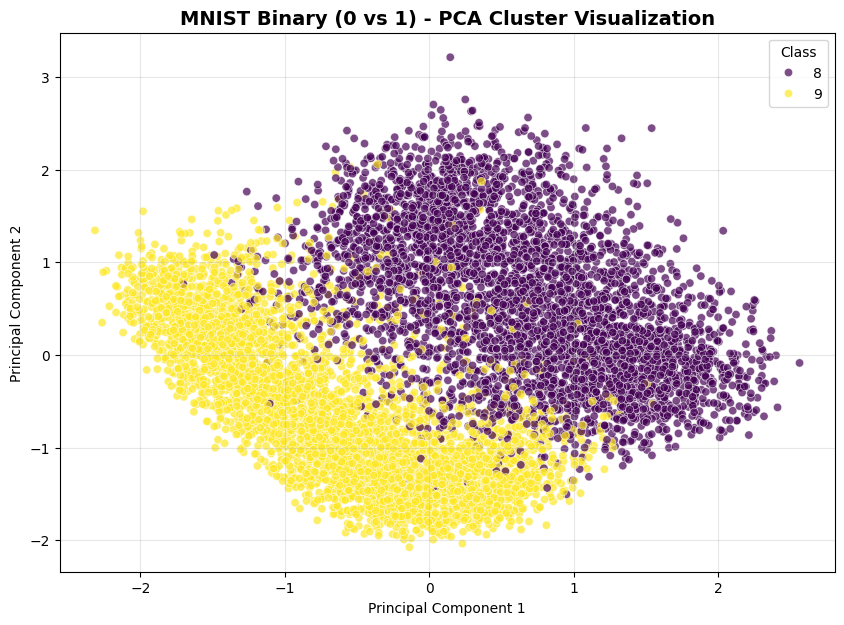

In [10]:
train_pca, _, _ = features['pca']
plt.figure(figsize=(10, 7))
sns.scatterplot(x=train_pca[:, 0], y=train_pca[:, 1], hue=y_train, palette='viridis', alpha=0.7)
plt.title('MNIST Binary (0 vs 1) - PCA Cluster Visualization', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.legend(title='Class')
plt.show()

## 5) Naive_Bayes Model

In [11]:
# Train Naive Bayes for each feature method
all_results = {}   # method -> {None: metrics}

for method in feature_methods:
    train_f, val_f, _ = features[method]
    print(f'\n===== {method.upper()} features =====')
    model = NaiveBayes()
    model.fit(train_f, y_train)
    y_train_pred = model.predict(train_f)
    y_val_pred = model.predict(val_f)
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    results = {None: {'val_accuracy': val_acc, 'train_accuracy': train_acc}}
    all_results[method] = results
    print(f'val accuracy = {val_acc:.4f} \ntrain accuracy = {train_acc:.4f}')


===== FLATTEN features =====
val accuracy = 0.9372 
train accuracy = 0.9267

===== HOG features =====
val accuracy = 0.9706 
train accuracy = 0.9696

===== PCA features =====
val accuracy = 0.8273 
train accuracy = 0.8309


## 6) Model Evaluation and Results

In [12]:
# Final evaluation on TEST set for each method
test_results_all = {}

for method in feature_methods:
    train_f, _, test_f = features[method]
    print(f'\n===== {method.upper()} on TEST set =====')
    model = NaiveBayes()
    model.fit(train_f, y_train)
    
    y_pred = model.predict(test_f)

    result = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='macro'),
        'recall': recall_score(y_test, y_pred, average='macro'),
        'f1_score': f1_score(y_test, y_pred, average='macro'),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'per_class_accuracy': per_class_accuracy(y_test, y_pred),
        'test_preds': y_pred,
    }

    test_results_all[method] = result
    print(f'  Accuracy:  {result["accuracy"]:.4f}')
    print(f'  Precision: {result["precision"]:.4f}')
    print(f'  Recall:    {result["recall"]:.4f}')
    print(f'  F1 Score:  {result["f1_score"]:.4f}')


===== FLATTEN on TEST set =====
  Accuracy:  0.9296
  Precision: 0.9310
  Recall:    0.9287
  F1 Score:  0.9294

===== HOG on TEST set =====
  Accuracy:  0.9684
  Precision: 0.9688
  Recall:    0.9681
  F1 Score:  0.9684

===== PCA on TEST set =====
  Accuracy:  0.8197
  Precision: 0.8196
  Recall:    0.8191
  F1 Score:  0.8193


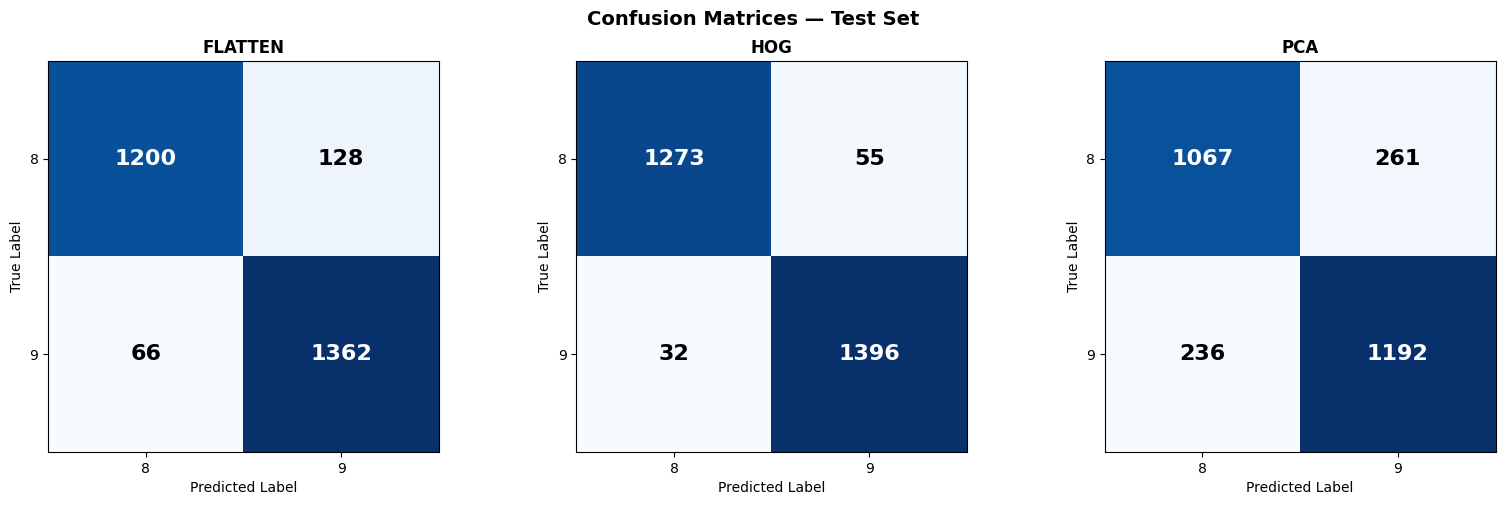

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = [CLASS_A, CLASS_B]

for ax, method in zip(axes, feature_methods):
    cm = test_results_all[method]['confusion_matrix']
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{method.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Annotate cells with counts
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=16, fontweight='bold', color=color)

fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Summary

In [15]:
# Final summary of results
print('=' * 60)
print('FINAL SUMMARY')
print('=' * 60)
print(f'Classes: {CLASS_A} vs {CLASS_B}')
print(f'Train size: {len(y_train)} (balanced)  |  Val: {len(y_val)}  |  Test: {len(y_test)}')
print()
print(f'{"Method":<10} {"Test Acc":>9}  {"Test F1":>8}')
print('-' * 30)
for method in feature_methods:
    m = test_results_all[method]
    print(f'{method.upper():<10} {m["accuracy"]:>9.4f}  {m["f1_score"]:>8.4f}')
print()

# Identify best method
best_method = max(test_results_all, key=lambda method: test_results_all[method]['f1_score'])
print(f'Best overall: {best_method.upper()} (Naive Bayes) (Accuracy={test_results_all[best_method]["accuracy"]:.4f})')

# Show classification report for the best model
print(f"\n\nClassification Report for {best_method.upper()}:\n")
print(classification_report(y_test, test_results_all[best_method]['test_preds']))

FINAL SUMMARY
Classes: 8 vs 9
Train size: 8230 (balanced)  |  Val: 2756  |  Test: 2756

Method      Test Acc   Test F1
------------------------------
FLATTEN       0.9296    0.9294
HOG           0.9684    0.9684
PCA           0.8197    0.8193

Best overall: HOG (Naive Bayes) (Accuracy=0.9684)


Classification Report for HOG:

   precision       recall     f1-score      support

           8       0.9755       0.9586       0.9670         1328
           9       0.9621       0.9776       0.9698         1428

    accuracy                                 0.9684         2756
   macro avg       0.9688       0.9681       0.9684         2756

